In [1]:
%matplotlib inline
import math, time, random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

SEED = 0
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("torch", torch.__version__, "| device:", device)


torch 2.12.0 | device: mps


In [2]:
# Task: learn (a + b) mod p.
# Sequence = [a, b, "="]  ->  predict (a + b) % p at the "=" position.
P = 97
EQ = P                      # the "=" token id, just past the number tokens 0..P-1
VOCAB = P + 1
SEQ_LEN = 3

# every (a, b) pair
a = torch.arange(P).repeat_interleave(P)
b = torch.arange(P).repeat(P)
eq = torch.full_like(a, EQ)
X = torch.stack([a, b, eq], dim=1)          # (P*P, 3)
Y = (a + b) % P                             # (P*P,)

# fixed shuffle, then split into train / val
g = torch.Generator().manual_seed(SEED)
perm = torch.randperm(P * P, generator=g)
X, Y = X[perm], Y[perm]

TRAIN_FRAC = 0.5
n_train = int(TRAIN_FRAC * P * P)
Xtr, Ytr = X[:n_train].to(device), Y[:n_train].to(device)
Xva, Yva = X[n_train:].to(device), Y[n_train:].to(device)

print(f"p={P}  vocab={VOCAB}  total={P*P}  train={len(Xtr)}  val={len(Xva)}")
ex = X[0]
print("example  x:", ex.tolist(), " y:", Y[0].item(),
      f"   ({ex[0].item()} + {ex[1].item()}) % {P} = {Y[0].item()}")


p=97  vocab=98  total=9409  train=4704  val=4705
example  x: [28, 57, 97]  y: 85    (28 + 57) % 97 = 85


In [3]:
class Block(nn.Module):
    def __init__(self, d_model, n_heads, d_mlp):
        super().__init__()
        self.ln1 = nn.LayerNorm(d_model)
        self.attn = nn.MultiheadAttention(d_model, n_heads, batch_first=True)
        self.ln2 = nn.LayerNorm(d_model)
        self.mlp = nn.Sequential(nn.Linear(d_model, d_mlp), nn.GELU(), nn.Linear(d_mlp, d_model))

    def forward(self, x):
        h = self.ln1(x)
        x = x + self.attn(h, h, h, need_weights=False)[0]
        x = x + self.mlp(self.ln2(x))
        return x

class Grokformer(nn.Module):
    def __init__(self, vocab, seq_len, d_model=128, n_heads=4, d_mlp=512, n_layers=1):
        super().__init__()
        self.tok_emb = nn.Embedding(vocab, d_model)
        self.pos_emb = nn.Embedding(seq_len, d_model)
        self.blocks = nn.ModuleList([Block(d_model, n_heads, d_mlp) for _ in range(n_layers)])
        self.ln_f = nn.LayerNorm(d_model)
        self.unembed = nn.Linear(d_model, vocab, bias=False)

    def forward(self, x):
        pos = torch.arange(x.shape[1], device=x.device)
        h = self.tok_emb(x) + self.pos_emb(pos)[None]
        for blk in self.blocks:
            h = blk(h)
        h = self.ln_f(h)
        return self.unembed(h)[:, -1, :]     # logits at the "=" position

model = Grokformer(VOCAB, SEQ_LEN).to(device)
n_params = sum(p.numel() for p in model.parameters())
print(model)
print(f"\n{n_params:,} parameters")


Grokformer(
  (tok_emb): Embedding(98, 128)
  (pos_emb): Embedding(3, 128)
  (blocks): ModuleList(
    (0): Block(
      (ln1): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
      (attn): MultiheadAttention(
        (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
      )
      (ln2): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
      (mlp): Sequential(
        (0): Linear(in_features=128, out_features=512, bias=True)
        (1): GELU(approximate='none')
        (2): Linear(in_features=512, out_features=128, bias=True)
      )
    )
  )
  (ln_f): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
  (unembed): Linear(in_features=128, out_features=98, bias=False)
)

224,000 parameters


In [4]:
WEIGHT_DECAY = 1.0     # the secret ingredient: heavy weight decay is what drives grokking
LR = 1e-3

opt = torch.optim.AdamW(model.parameters(), lr=LR, betas=(0.9, 0.98),
                        weight_decay=WEIGHT_DECAY)

history = {"step": [], "train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
gstep = 0

@torch.no_grad()
def evaluate(Xs, Ys):
    model.eval()
    logits = model(Xs)
    loss = F.cross_entropy(logits, Ys).item()
    acc = (logits.argmax(-1) == Ys).float().mean().item()
    model.train()
    return loss, acc

def train(n_steps, log_every=100):
    global gstep
    t0 = time.time()
    for _ in range(n_steps):
        logits = model(Xtr)                       # full-batch
        loss = F.cross_entropy(logits, Ytr)
        opt.zero_grad(); loss.backward(); opt.step()
        gstep += 1
        if gstep == 1 or gstep % log_every == 0:
            tl, ta = evaluate(Xtr, Ytr)
            vl, va = evaluate(Xva, Yva)
            history["step"].append(gstep)
            history["train_loss"].append(tl); history["val_loss"].append(vl)
            history["train_acc"].append(ta);  history["val_acc"].append(va)
    dt = time.time() - t0
    print(f"ran {n_steps} steps in {dt:.1f}s ({n_steps/max(dt,1e-9):.0f} step/s) | "
          f"step {gstep}: train_acc={history['train_acc'][-1]:.3f} "
          f"val_acc={history['val_acc'][-1]:.3f}")

print("ready -> call train(n_steps)")


ready -> call train(n_steps)


In [5]:
train(2000, log_every=50)


ran 2000 steps in 30.4s (66 step/s) | step 2000: train_acc=1.000 val_acc=1.000


In [6]:
import numpy as np
s  = np.array(history["step"]); ta = np.array(history["train_acc"]); va = np.array(history["val_acc"])
def first(arr, thr):
    if (arr >= thr).any():
        return int(s[np.argmax(arr >= thr)])
    return None
print("train_acc >= 0.95 at step:", first(ta, 0.95))
print("val_acc   >= 0.50 at step:", first(va, 0.50))
print("val_acc   >= 0.95 at step:", first(va, 0.95))
print("grokking gap (val0.95 - train0.95):",
      (first(va,0.95) or 0) - (first(ta,0.95) or 0), "steps\n")
for i in range(0, len(s), max(1, len(s)//18)):
    print(f"step {s[i]:5d}   train {ta[i]:.3f}   val {va[i]:.3f}")


train_acc >= 0.95 at step: 150
val_acc   >= 0.50 at step: 1350
val_acc   >= 0.95 at step: 1700
grokking gap (val0.95 - train0.95): 1550 steps

step     1   train 0.012   val 0.009
step   100   train 0.360   val 0.003
step   200   train 0.996   val 0.033
step   300   train 0.992   val 0.036
step   400   train 1.000   val 0.061
step   500   train 1.000   val 0.071
step   600   train 1.000   val 0.075
step   700   train 1.000   val 0.091
step   800   train 1.000   val 0.111
step   900   train 0.867   val 0.059
step  1000   train 1.000   val 0.173
step  1100   train 1.000   val 0.245
step  1200   train 0.999   val 0.310
step  1300   train 0.326   val 0.063
step  1400   train 1.000   val 0.567
step  1500   train 1.000   val 0.747
step  1600   train 0.174   val 0.036
step  1700   train 1.000   val 0.991
step  1800   train 1.000   val 0.998
step  1900   train 1.000   val 0.999
step  2000   train 1.000   val 1.000


In [7]:
train(1500, log_every=50)


ran 1500 steps in 18.4s (81 step/s) | step 3500: train_acc=1.000 val_acc=1.000


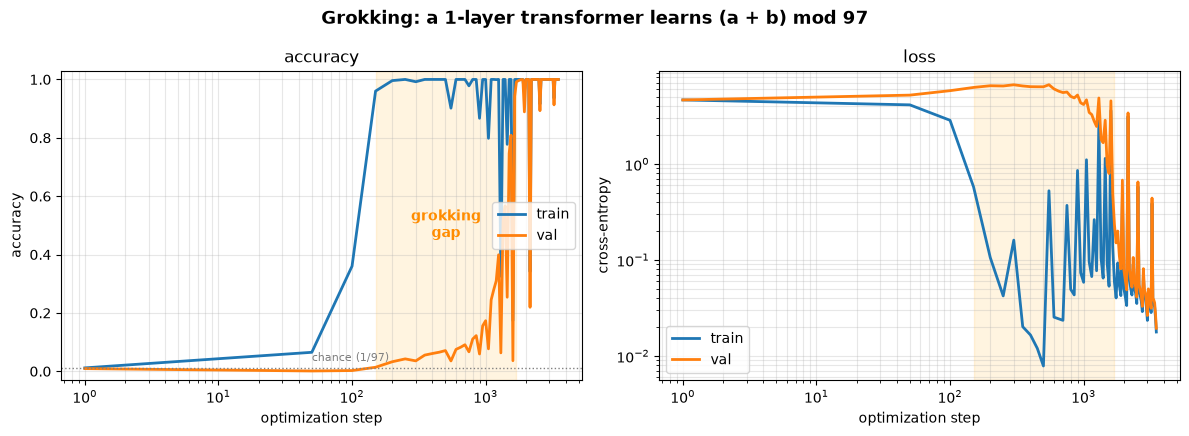

memorized (train>=95%) at step 150  |  generalized (val>=95%) at step 1700  |  gap = 1550 steps


In [8]:
s  = np.array(history["step"])
ta = np.array(history["train_acc"]); va = np.array(history["val_acc"])
tl = np.array(history["train_loss"]); vl = np.array(history["val_loss"])

mem = int(s[np.argmax(ta >= 0.95)])     # memorized
gen = int(s[np.argmax(va >= 0.95)])     # generalized

fig, ax = plt.subplots(1, 2, figsize=(12, 4.4))

# --- accuracy ---
ax[0].plot(s, ta, lw=2, label="train")
ax[0].plot(s, va, lw=2, label="val")
ax[0].axhline(1/P, ls=":", c="grey", lw=1)
ax[0].text(s[1], 1/P + 0.025, "chance (1/97)", fontsize=8, color="grey")
ax[0].axvspan(mem, gen, color="orange", alpha=0.12)
ax[0].text(math.sqrt(mem * gen), 0.46, "grokking\ngap", ha="center",
           color="darkorange", fontsize=10, weight="bold")
ax[0].set(title="accuracy", xlabel="optimization step", ylabel="accuracy",
          xscale="log", ylim=(-0.03, 1.03))
ax[0].legend(loc="center right"); ax[0].grid(alpha=0.3, which="both")

# --- loss ---
ax[1].plot(s, tl, lw=2, label="train")
ax[1].plot(s, vl, lw=2, label="val")
ax[1].axvspan(mem, gen, color="orange", alpha=0.12)
ax[1].set(title="loss", xlabel="optimization step", ylabel="cross-entropy",
          xscale="log", yscale="log")
ax[1].legend(); ax[1].grid(alpha=0.3, which="both")

fig.suptitle(f"Grokking: a 1-layer transformer learns (a + b) mod {P}",
             fontsize=13, weight="bold")
fig.tight_layout()
plt.show()
print(f"memorized (train>=95%) at step {mem}  |  "
      f"generalized (val>=95%) at step {gen}  |  gap = {gen - mem} steps")


key frequencies (>5% variance each): [9, 12, 14, 15, 40, 41]
they capture 64% of the variance in just 6/48 frequencies


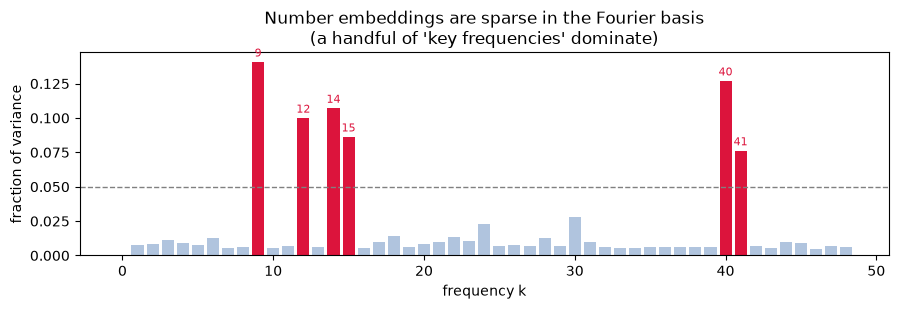

In [9]:
# Reverse-engineering: the learned number embeddings are SPARSE in the Fourier basis.
W = model.tok_emb.weight.detach().cpu().numpy()[:P]
W = W - W.mean(0, keepdims=True)

F = np.fft.rfft(W, axis=0)
power = (np.abs(F) ** 2).sum(1)
power = power / power.sum()
freqs = np.arange(len(power))

THRESH = 0.05
key = freqs[power > THRESH].tolist()
print("key frequencies (>5% variance each):", key)
print(f"they capture {power[power > THRESH].sum() * 100:.0f}% of the variance "
      f"in just {len(key)}/{len(freqs) - 1} frequencies")

colors = ["crimson" if p > THRESH else "lightsteelblue" for p in power]
plt.figure(figsize=(9, 3.2))
plt.bar(freqs, power, color=colors)
plt.axhline(THRESH, ls="--", c="grey", lw=1)
for k in key:
    plt.text(k, power[k] + 0.004, str(k), ha="center", fontsize=8, color="crimson")
plt.xlabel("frequency k"); plt.ylabel("fraction of variance")
plt.title("Number embeddings are sparse in the Fourier basis\n"
          "(a handful of 'key frequencies' dominate)")
plt.tight_layout()
plt.show()


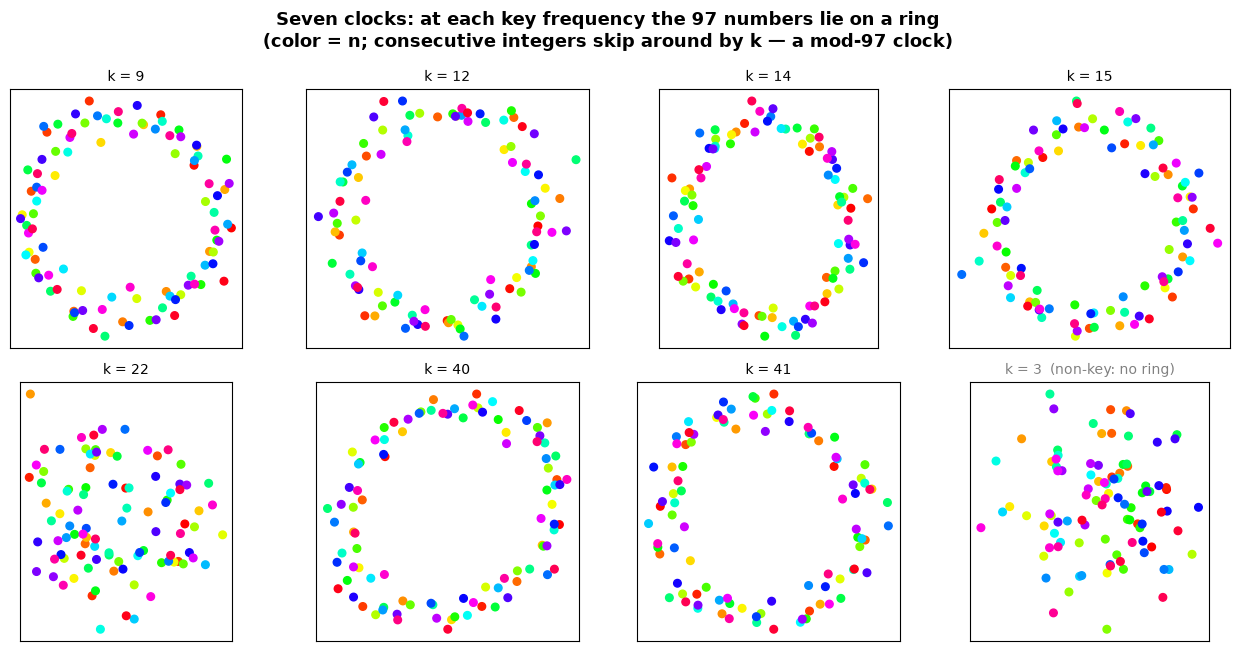

In [10]:
# Honest "clock" view: project the embedding onto each key frequency's own 2D
# Fourier plane. If the model built a clock at frequency k, the 97 numbers
# should land on a clean ring there (and nowhere else).
n = np.arange(P)
keyfreqs = [9, 12, 14, 15, 22, 40, 41]

def clock_coords(emb, k):
    c = np.cos(2 * np.pi * k * n / P); s = np.sin(2 * np.pi * k * n / P)
    A = c @ emb; B = s @ emb                         # embedding's Fourier dirs at k
    Q, _ = np.linalg.qr(np.stack([A, B], axis=1))    # orthonormal basis of that plane
    return emb @ Q                                   # [97, 2] coordinates

fig, axes = plt.subplots(2, 4, figsize=(13, 6.6))
for ax_, k in zip(axes.flat, keyfreqs):
    xy = clock_coords(W, k)
    ax_.scatter(xy[:, 0], xy[:, 1], c=n, cmap="hsv", s=30, zorder=3)
    ax_.set_title(f"k = {k}", fontsize=10)
    ax_.set_aspect("equal"); ax_.set_xticks([]); ax_.set_yticks([])
    ax_.grid(alpha=0.25)
axes.flat[-1].axis("off")    # hide unused 8th panel

# control: a non-key frequency should NOT form a ring
xy = clock_coords(W, 3)
axes.flat[-1].axis("on")
axes.flat[-1].scatter(xy[:, 0], xy[:, 1], c=n, cmap="hsv", s=30)
axes.flat[-1].set_title("k = 3  (non-key: no ring)", fontsize=10, color="grey")
axes.flat[-1].set_aspect("equal"); axes.flat[-1].set_xticks([]); axes.flat[-1].set_yticks([])

fig.suptitle("Seven clocks: at each key frequency the 97 numbers lie on a ring\n"
             "(color = n; consecutive integers skip around by k — a mod-97 clock)",
             fontsize=13, weight="bold")
fig.tight_layout()
plt.show()


In [11]:
from IPython.display import HTML
HTML("""
<div style="font-family:system-ui;border:1px solid #d9ddd4;border-radius:10px;
            padding:14px 18px;max-width:560px;background:#ffffff">
  <h3 style="margin:0 0 6px;color:#0f766e">Hello from <code>text/html</code> &#128075;</h3>
  <p style="margin:0;color:#333">If this shows up styled &mdash; teal heading, rounded
  card &mdash; then the kernel emitted a <b>text/html</b> MIME bundle and Notebook Lens
  captured it.</p>
</div>
""")


In [12]:
from IPython.display import HTML
import numpy as np

s  = np.array(history["step"]); ta = np.array(history["train_acc"]); va = np.array(history["val_acc"])
mem = int(s[np.argmax(ta >= 0.95)]); gen = int(s[np.argmax(va >= 0.95)])
nparams = sum(p.numel() for p in model.parameters())

rows = [
    ("Task",                     f"(a + b) mod {P}"),
    ("Device",                   str(device)),
    ("Parameters",               f"{nparams:,}"),
    ("Memorized (train &ge; 95%)", f"step {mem}"),
    ("Generalized (val &ge; 95%)", f"step {gen}"),
    ("Grokking gap",             f"<b style='color:#dc2626'>{gen - mem} steps</b>"),
    ("Final val accuracy",       f"{va[-1] * 100:.1f}%"),
    ("Key Fourier frequencies",  ", ".join(map(str, keyfreqs))),
]
trs = "".join(
    f"<tr style='background:{'#f7f7f4' if i % 2 else '#ffffff'}'>"
    f"<td style='padding:7px 16px;color:#6f746d'>{k}</td>"
    f"<td style='padding:7px 16px;text-align:right;font-weight:600'>{v}</td></tr>"
    for i, (k, v) in enumerate(rows)
)
HTML(f"""
<table style="font-family:system-ui;border-collapse:collapse;min-width:420px;
              border:1px solid #d9ddd4;border-radius:10px;overflow:hidden;
              box-shadow:0 1px 3px rgba(0,0,0,.06)">
  <caption style="caption-side:top;text-align:left;font-weight:700;font-size:15px;
                  padding:10px 16px;color:#102027;background:#0f766e0d">
    &#9201; Grokking run summary
  </caption>{trs}
</table>
""")


Task,(a + b) mod 97
Device,mps
Parameters,"224,000"
Memorized (train ≥ 95%),step 150
Generalized (val ≥ 95%),step 1700
Grokking gap,1550 steps
Final val accuracy,100.0%
Key Fourier frequencies,"9, 12, 14, 15, 22, 40, 41"


In [13]:
from IPython.display import HTML
import math

A_ex, B_ex = 70, 40
C_ex = (A_ex + B_ex) % P            # 110 -> 13  (wraps past 0)
R, cx, cy = 150, 175, 175

def pt(n, r=R):
    th = 2 * math.pi * n / P
    return cx + r * math.sin(th), cy - r * math.cos(th)   # n=0 at top, clockwise

ticks = "".join(
    f'<circle cx="{pt(n)[0]:.1f}" cy="{pt(n)[1]:.1f}" r="2" fill="#c7ccc2"/>'
    for n in range(P)
)

def hand(n, color, label):
    x, y = pt(n)
    lx, ly = cx + 1.16 * (x - cx), cy + 1.16 * (y - cy)
    return (f'<line x1="{cx}" y1="{cy}" x2="{x:.1f}" y2="{y:.1f}" '
            f'stroke="{color}" stroke-width="2.5"/>'
            f'<circle cx="{x:.1f}" cy="{y:.1f}" r="6" fill="{color}"/>'
            f'<text x="{lx:.1f}" y="{ly:.1f}" font-size="13" fill="{color}" '
            f'text-anchor="middle" dominant-baseline="middle" font-weight="700">{label}</text>')

svg = f'''<svg width="350" height="360" viewBox="0 0 350 360" font-family="system-ui">
  <circle cx="{cx}" cy="{cy}" r="{R}" fill="#ffffff" stroke="#d9ddd4" stroke-width="2"/>
  <circle cx="{cx}" cy="{cy}" r="2.5" fill="#102027"/>
  {ticks}
  <text x="{pt(0, R + 16)[0]:.0f}" y="{pt(0, R + 16)[1]:.0f}" font-size="12"
        fill="#6f746d" text-anchor="middle" dominant-baseline="middle">0</text>
  {hand(A_ex, "#2563eb", A_ex)}
  {hand(B_ex, "#16a34a", B_ex)}
  {hand(C_ex, "#dc2626", C_ex)}
</svg>'''

HTML(f'''
<div style="display:flex;gap:22px;align-items:center;font-family:system-ui;flex-wrap:wrap">
  {svg}
  <div style="max-width:250px;color:#333;line-height:1.5">
    <div style="font-size:16px;font-weight:700;color:#102027">
      Modular addition is clock arithmetic
    </div>
    <p>Space the numbers 0&hellip;{P-1} evenly around a circle. Start at
      <span style="color:#2563eb;font-weight:700">{A_ex}</span>, walk
      <span style="color:#16a34a;font-weight:700">{B_ex}</span> more steps clockwise,
      and you wrap past 0 to land on
      <span style="color:#dc2626;font-weight:700">{C_ex}</span>:</p>
    <p style="font-size:18px;text-align:center;margin:10px 0">
      ({A_ex} + {B_ex}) mod {P} =
      <span style="color:#dc2626;font-weight:700">{C_ex}</span></p>
    <p style="color:#6f746d;font-size:13px;margin-bottom:0">That is exactly the trick the
      grokked model discovered &mdash; running {len(keyfreqs)} such clocks at once.</p>
  </div>
</div>
''')


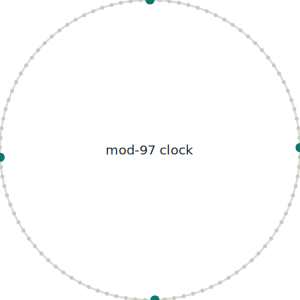

In [19]:
# image/svg+xml  via  IPython.display.SVG  (a genuine SVG image, not SVG-inside-HTML)
from IPython.display import SVG
import math

cx = cy = 150; R = 150
def pt(n, r=R):
    th = 2 * math.pi * n / P
    return cx + r * math.sin(th), cy - r * math.cos(th)

ticks = "".join(
    f'<circle cx="{pt(n)[0]:.1f}" cy="{pt(n)[1]:.1f}" r="2" fill="#c7ccc2"/>'
    for n in range(P))
marks = "".join(
    f'<circle cx="{pt(m)[0]:.1f}" cy="{pt(m)[1]:.1f}" r="4.5" fill="#0f766e"/>'
    f'<text x="{pt(m, R + 18)[0]:.1f}" y="{pt(m, R + 18)[1]:.1f}" font-size="12" '
    f'fill="#0f766e" text-anchor="middle" dominant-baseline="middle">{m}</text>'
    for m in (0, 24, 48, 72))

svg = f'''<svg xmlns="http://www.w3.org/2000/svg" width="300" height="300"
     viewBox="0 0 300 300" font-family="system-ui">
  <circle cx="{cx}" cy="{cy}" r="{R}" fill="#ffffff" stroke="#d9ddd4" stroke-width="2"/>
  {ticks}{marks}
  <text x="{cx}" y="{cy}" font-size="13" fill="#102027"
        text-anchor="middle" dominant-baseline="middle">mod-97 clock</text>
</svg>'''
SVG(svg)


In [18]:
# text/latex  via  IPython.display.Latex  -- the actual algorithm the model grokked
from IPython.display import Latex
Latex(r"""For each key frequency $k$ the model puts $a$ and $b$ on a clock and combines
their angles with the cosine angle-addition identity
$$\cos\big(\omega_k(a+b)\big)=\cos(\omega_k a)\cos(\omega_k b)-\sin(\omega_k a)\sin(\omega_k b),
\qquad \omega_k=\frac{2\pi k}{97},$$
then the unembedding turns that into the logit for the answer $c$:
$$\mathrm{logit}(c)\;\propto\;\sum_{k\in K}\cos\big(\omega_k\,(a+b-c)\big),
\qquad K=\{9,12,14,15,22,40,41\}.$$""")


<IPython.core.display.Latex object>